# Tutorial: Introduction to CommonRoad Interactive Benchmark
## Converting CommonRoad Static Scenario to Interactive Scenario

## 0. Preparation
Before you proceed with this tutorial, we highly recommend that:
* you have gone through the tutorials on [CommonRoad Input-Output](https://gitlab.lrz.de/tum-cps/commonroad-search/-/blob/master/tutorials/0_commonroad_input-output/tutorial_commonroad_input-output.ipynb) and have a basic understanding of the CommonRoad static scenarios.
* you have gone through the tutorials on [SUMO(Simulation of Urban MObility)](https://sumo.dlr.de/docs/Tutorials.html) and have the basis information about SUMO network.
* you have successfully installed all necessary modules for the interactive benchmark by running the installation script.

It's also fine if you go through this tutorial first, as we will introduce the things that are required here as well.

## 1. CommonRoad static scenario
To start with, a CommonRoad XML-file consists of a **Scenario** and a **PlanningProblemSet**:

* A **Scenario** represents the environment, which includes a **LaneletNetwork** and a set of **DynamicObstacle** and **StaticObstacle**.
    * A **LaneletNetwork** consists of a set of lane segments (**Lanelets**) that can be connected arbitrarily.
* A **PlanningProblemSet** contains one **PlanningProblem** for every ego vehicle in the **Scenario**, which in turn has an **initial position** and a to-be-reached **GoalRegion**.

Here we just introduce how to read a CommonRoad xml scenario with the **CommonRoadFileReader**, and its **open()** function returns a **Scenario** and a **PlanningProblemSet** object.

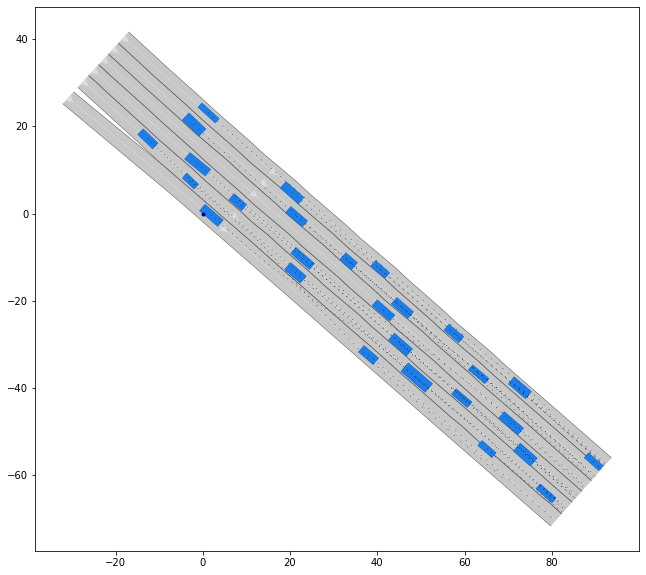

In [3]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import os
import matplotlib.pyplot as plt
from IPython import display

# import classes and functions for reading xml file and visualizing commonroad objects
from commonroad.common.file_reader import CommonRoadFileReader
from commonroad.visualization.draw_dispatch_cr import draw_object

# generate path of the file to be read
path_file = "../example_scenarios/cr_scenario/USA_US101-26_2_T-1.xml"

# read in the scenario and planning problem set
scenario, planning_problem_set = CommonRoadFileReader(path_file).open()

# plot the scenario for 40 time steps, here each time step corresponds to 0.1 second

for i in range(0, len(scenario.obstacles[0].prediction.trajectory.state_list)): 
    # uncomment the following line to clear previous graph for better visualization
    display.clear_output(wait=True)
    plt.figure(figsize=(25, 10))
    # plot the scenario for each time step
    draw_object(scenario, draw_params={'time_begin': i})
    # plot the planning problem set
    draw_object(planning_problem_set)
    plt.gca().set_aspect('equal')
    plt.show()

Why is it static? In the following block you can see that the trajectory of all obstacle vehicles are already predefined and is not affected by the motion of ego vehicle.

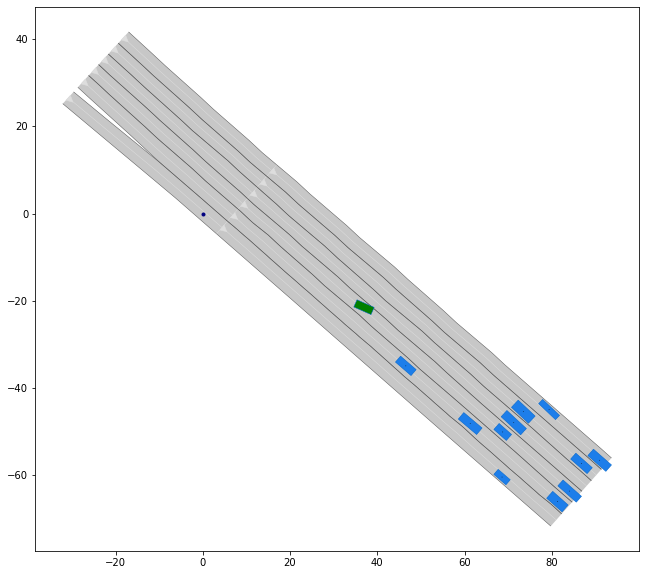

In [6]:
from utility import visualize_solution
from commonroad.common.solution import CommonRoadSolutionReader

solution_reader = CommonRoadSolutionReader()
solution_path = "../example_scenarios/solution/KS2:SM1:USA_US101-26_2_T-1:2020a.xml"

solution = solution_reader.open(solution_path)
visualize_solution(scenario, planning_problem_set, solution.planning_problem_solutions[0].trajectory)

More information about modifying a static CommonRoad xml scenario can be found in [CommonRoad Tutorial](https://gitlab.lrz.de/ss20-mpfav/graph-search-planner/-/tree/master/tutorials). In the next step, we will take a look into another traffic simulation package - [SUMO](https://sumo.dlr.de/docs/index.html). 

## 2. SUMO network
Normally a SUMO network with the name of 'MapName' consists of the following files stored in the *MapName* folder: 

* **nodes.net.xml** is a Sumo node file defining all the nodes in the network.
* **edges.net.xml** is a Sumo edge file defining the edges connecting nodes in the network.
* **MapName.net.xml** is a net file defining the SUMO network. A SUMO network can be either converted from node and edges, or created by using SUMO-GUI.
* **MapName.vehicles.rou.xml** is a Sumo route file defining the vehicles and their route in the network. 
* **MapName.sumo.cfg**: SUMO simulation configuration file defining the configurations of a simulation which can be started either by SUMO or SUMO-GUI.
* **MapName.add.xml**: Saving additional informations such as acceleration and deceleration of a vehicle model.

In the following gif you can see the same scenario simulated by SUMO and demonstrated by SUMO-GUI


![SegmentLocal](sumo.gif "segment")

## 3. Conversion from CommonRoad scenario to interactive scenario.

The conversion from CommonRoad static scenario to interactive scenario is implemented by the function **convert_scenario** with the following arguments:

* **cr_scenario_path**: The path of the input CommonRoad xml scenario. 
* **output_folder_path**: The path of the output folder. After the conversion a folder saving all the converted files will be created in thie path. 
* **config_type**: The configuration file. You can find the configuration file in "./configuration" folder. **default**: CONFIG_TYPE.SUMO_CONFIG_1
* **creating_video**: Boolean value determines whether to create a video or not. **default**: False. (If it is set to True, then you will encounter the **NotImplementedError**.)


In [7]:
import sys
sys.path.append("..")
from scenario_converter.convert_scenarios import convert_scenario
from configuration import CONFIG_TYPE

cr_scenario_path  = "../example_scenarios/cr_scenario/USA_US101-26_2_T-1.xml"
output_folder_path = "../example_scenarios/output/tutorial_1"
config_type = CONFIG_TYPE.SUMO_CONFIG_1
creating_video = False

convert_scenario(cr_scenario_path  = cr_scenario_path,
                output_folder_path = output_folder_path,
                config_type = config_type,
                creating_video = creating_video)


Write SUMO files for ../example_scenarios/cr_scenario/USA_US101-26_2_T-1.xml


/home/zen/anaconda3/envs/cr37/lib/python3.7/site-packages/commonroad/common/file_writer.py:563: UserWarning: <CommonRoadFileWriter/lanelet.lanelet_type> Lanelet 30 has no lanelet type! Default lanelet type is used!
  'lanelet type! Default lanelet type is used!' % lanelet.lanelet_id)
/home/zen/anaconda3/envs/cr37/lib/python3.7/site-packages/commonroad/common/file_writer.py:563: UserWarning: <CommonRoadFileWriter/lanelet.lanelet_type> Lanelet 28 has no lanelet type! Default lanelet type is used!
  'lanelet type! Default lanelet type is used!' % lanelet.lanelet_id)
/home/zen/anaconda3/envs/cr37/lib/python3.7/site-packages/commonroad/common/file_writer.py:563: UserWarning: <CommonRoadFileWriter/lanelet.lanelet_type> Lanelet 49 has no lanelet type! Default lanelet type is used!
  'lanelet type! Default lanelet type is used!' % lanelet.lanelet_id)
/home/zen/anaconda3/envs/cr37/lib/python3.7/site-packages/commonroad/common/file_writer.py:563: UserWarning: <CommonRoadFileWriter/lanelet.lanele

(True, '../example_scenarios/output/tutorial_1/USA_US101-26_2_T-1-1')

The interactive scenario is not just one file, rather it is a combination of files saved in the output folder. After the conversion, you should have the following files in the output folder:

In [11]:
from os import listdir
from os.path import isfile, join
output_path = "../example_scenarios/output/tutorial_1/USA_US101-26_2_T-1-1"
onlyfiles = [f for f in listdir(output_path) if isfile(join(output_path, f))]
print(onlyfiles)

['_connections.net.xml', 'USA_US101-26_2_T-1-1.add.xml', 'USA_US101-26_2_T-1-1.sumo.cfg', 'edges.net.xml', 'nodes.net.xml', '_tll.net.xml', 'USA_US101-26_2_T-1-1.cr.xml', 'simulation_config.p', 'USA_US101-26_2_T-1-1.pedestrians.rou.xml', 'USA_US101-26_2_T-1-1.vehicles.rou.xml', 'USA_US101-26_2_T-1-1.net.xml']


From the names of the files we can explain briefly what has been done during the conversion.
* The static CommonRoad scenario **MapName.xml** is reduced to only the initial state of all the obstacle vehicles and saved as **MapName.cr.xml**.
* The CommonRoad lanelet network is converted to the corresponding SUMO network and is saved as **nodes.net.xml**, **edges.net.xml**, and **MapName.net.xml**.
* The trajcetory of obstacle vehicles in CommonRoad scenario is converted to the route of vehicles in SUMO and saved as **MapName.vehicle.rou.xml** and **MapName.sumo.cfg**.
* Finally the configuration of the simulation is saved in the **simulation_config.p**.


## Congratulations! 
A static CommonRoad scenario has been successfully converted to a interactive scenario. However, now the interactivity has not been shown as no ego vehicle trajectory (latter we also call it a 'solution') are given and we must run a simulation to demonstrate the interactivity. (see tutorial 2)